# Покрытия пола: SegFormer + DINOv2

SegFormer отдельно выделяет `floor` и `rug`. Если вокруг ковра видна достаточная область настоящего пола, модель классифицирует именно её и игнорирует переносной ковёр. Маска `rug` используется только тогда, когда другой пол практически не виден — это позволяет сохранить класс ковролина. DINOv2 анализирует всю найденную область и девять локальных участков.


In [1]:
from pathlib import Path
import base64, hashlib, json, random, re, shutil
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image, ImageOps, ImageDraw
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoImageProcessor, AutoModel, SegformerForSemanticSegmentation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from scipy import ndimage
import matplotlib.pyplot as plt

PROJECT = Path('/Users/himynameisartem/Documents/Development/ML/Renovation_calculator_CV')
DATA = PROJECT / 'data/dataset/floors'
OUT = PROJECT / 'outputs/floor_training/current'
OUT.mkdir(parents=True, exist_ok=True)

EXPECTED_CLASSES = {'bare_unfinished_floor', 'tile_or_stone', 'wood_flooring', 'vinyl_or_linoleum', 'carpet'}
SEED = 42
INPUT_SIZE = 384
MAX_FLOOR_VIEWS_PER_IMAGE = 3
LOCAL_VIEWS_PER_FLOOR = 9
LOCAL_INPUT_SIZE = 320
MIN_COMPONENT_AREA = 0.03
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)
print('Classes:', sorted(EXPECTED_CLASSES))
print('Results:', OUT)


Device: mps
Classes: ['bare_unfinished_floor', 'carpet', 'tile_or_stone', 'vinyl_or_linoleum', 'wood_flooring']
Results: /Users/himynameisartem/Documents/Development/ML/Renovation_calculator_CV/outputs/floor_training/current


## 1. Исходные фотографии и разделение 70/15/15

Точные дубликаты удаляются. Кадры одного объявления определяются по префиксу имени файла и целиком попадают только в train, validation или test.


In [2]:
extensions = {'.jpg','.jpeg','.png','.webp','.bmp','.tif','.tiff'}
rows, unreadable = [], []
actual_classes = {folder.name for folder in DATA.iterdir() if folder.is_dir()}
assert actual_classes == EXPECTED_CLASSES, f'Ожидались {sorted(EXPECTED_CLASSES)}, найдены {sorted(actual_classes)}'

for folder in sorted(DATA.iterdir()):
    for path in sorted(folder.rglob('*')):
        if not path.is_file() or path.suffix.lower() not in extensions:
            continue
        try:
            with Image.open(path) as source:
                image = ImageOps.exif_transpose(source).convert('RGB')
                digest = hashlib.sha256(f'{image.width}x{image.height}:'.encode() + image.tobytes()).hexdigest()
            filename = path.name.lower()
            listing_match = re.match(r'^([0-9a-f]{40})_', filename)
            reddit_match = re.match(r'^(.*?)-v0-', filename)
            if listing_match:
                group_key = listing_match.group(1)
            elif reddit_match:
                group_key = reddit_match.group(1)
            else:
                group_key = digest
            rows.append({
                'path': str(path.resolve()),
                'label': folder.name,
                'source_id': digest,
                'group_id': f'{folder.name}:{group_key}',
            })
        except (OSError, ValueError) as error:
            unreadable.append({'path':str(path), 'reason':str(error)})

raw = pd.DataFrame(rows)
assert len(raw), 'Нет читаемых изображений'
conflicting_ids = set(raw.groupby('source_id').label.nunique().loc[lambda x:x > 1].index)
raw[raw.source_id.isin(conflicting_ids)].to_csv(OUT/'conflicting_labels.csv', index=False)
pd.DataFrame(unreadable).to_csv(OUT/'unreadable.csv', index=False)
sources = raw[~raw.source_id.isin(conflicting_ids)].drop_duplicates('source_id').copy()
assert set(sources.label) == EXPECTED_CLASSES
assert sources.groupby('label').size().min() >= 10, 'В одном из классов меньше 10 исходных фото'
classes = sorted(EXPECTED_CLASSES)

groups = sources[['group_id','label']].drop_duplicates().reset_index(drop=True)
assert groups.groupby('group_id').label.nunique().max() == 1
train_groups, remainder_groups = train_test_split(
    groups, test_size=.30, stratify=groups.label, random_state=SEED
)
val_groups, test_groups = train_test_split(
    remainder_groups, test_size=.50, stratify=remainder_groups.label, random_state=SEED
)
group_split = pd.concat([
    train_groups.assign(split='train'),
    val_groups.assign(split='val'),
    test_groups.assign(split='test'),
], ignore_index=True)
source_manifest = sources.merge(group_split[['group_id','split']], on='group_id', how='left')
assert source_manifest.split.notna().all()
assert source_manifest.source_id.is_unique
assert source_manifest.groupby('group_id').split.nunique().max() == 1
source_manifest.to_csv(OUT/'source_split.csv', index=False)
display(pd.crosstab(source_manifest.label, source_manifest.split).reindex(columns=['train','val','test']))
display(pd.crosstab(group_split.label, group_split.split).reindex(columns=['train','val','test']))
print('Sources:', len(source_manifest), 'Groups:', len(group_split), 'Classes:', classes)


split,train,val,test
label,,,
bare_unfinished_floor,82,23,22
carpet,76,17,15
tile_or_stone,76,14,15
vinyl_or_linoleum,74,15,14
wood_flooring,77,12,16


split,train,val,test
label,,,
bare_unfinished_floor,14,3,3
carpet,72,15,15
tile_or_stone,62,13,14
vinyl_or_linoleum,68,15,14
wood_flooring,50,11,11


Sources: 548 Groups: 380 Classes: ['bare_unfinished_floor', 'carpet', 'tile_or_stone', 'vinyl_or_linoleum', 'wood_flooring']


## 2. Маска пола и локальные фрагменты

SegFormer сначала ищет маску `floor` отдельно от `rug`. При наличии достаточно крупного видимого участка пола ковёр исключается. Если такого участка нет, используется `rug`, чтобы распознавать сплошной ковролин. Для выбранной поверхности сохраняются её границы и девять локальных участков.


In [3]:
segmenter_name = 'nvidia/segformer-b0-finetuned-ade-512-512'
processor = AutoImageProcessor.from_pretrained(segmenter_name)
segmenter = SegformerForSemanticSegmentation.from_pretrained(segmenter_name).to(device).eval()
floor_id = next(int(k) for k,v in segmenter.config.id2label.items() if v == 'floor')
rug_id = next(int(k) for k,v in segmenter.config.id2label.items() if v == 'rug')

def box_iou(a,b):
    ax0,ay0,ax1,ay1=a; bx0,by0,bx1,by1=b
    intersection=max(0,min(ax1,bx1)-max(ax0,bx0))*max(0,min(ay1,by1)-max(ay0,by0))
    union=(ax1-ax0)*(ay1-ay0)+(bx1-bx0)*(by1-by0)-intersection
    return intersection/union if union else 0

def encode_small_mask(mask, max_side=160):
    image=Image.fromarray((mask.astype(np.uint8)*255),mode='L')
    scale=min(1.0,max_side/max(image.size))
    size=(max(1,round(image.width*scale)),max(1,round(image.height*scale)))
    image=image.resize(size,Image.Resampling.NEAREST)
    binary=np.asarray(image)>=128
    packed=np.packbits(binary.reshape(-1))
    return base64.b64encode(packed.tobytes()).decode('ascii'),binary.shape[0],binary.shape[1]

def decode_mask(mask_data,height,width,output_size):
    packed=np.frombuffer(base64.b64decode(mask_data),dtype=np.uint8)
    mask=np.unpackbits(packed,count=int(height)*int(width)).reshape(int(height),int(width))
    return Image.fromarray((mask*255).astype(np.uint8),mode='L').resize(output_size,Image.Resampling.NEAREST)

def select_local_boxes(component,offset_x,offset_y,sx,sy):
    h,w=component.shape
    size=max(48,int(min(w,h)*.30))
    size=min(size,w,h)
    integral=np.pad(component.astype(np.int32).cumsum(0).cumsum(1),((1,0),(1,0)))
    def coverage(x0,y0,x1,y1):
        value=integral[y1,x1]-integral[y0,x1]-integral[y1,x0]+integral[y0,x0]
        return float(value/((x1-x0)*(y1-y0)))
    stride=max(12,size//4);candidates=[]
    xs=list(range(0,w-size+1,stride));ys=list(range(0,h-size+1,stride))
    if xs and xs[-1]!=w-size:xs.append(w-size)
    if ys and ys[-1]!=h-size:ys.append(h-size)
    for y0 in ys:
        for x0 in xs:
            cov=coverage(x0,y0,x0+size,y0+size)
            if cov>=.72:
                candidates.append({'box':(x0,y0,x0+size,y0+size),'coverage':cov,'cx':(x0+size/2)/w,'cy':(y0+size/2)/h})
    if not candidates:
        candidates=[{'box':((w-size)//2,(h-size)//2,(w+size)//2,(h+size)//2),'coverage':0,'cx':.5,'cy':.5}]
    selected=[];used=set()
    for ty in (.17,.50,.83):
        for tx in (.17,.50,.83):
            ranked=sorted(enumerate(candidates),key=lambda item:(item[1]['cx']-tx)**2+(item[1]['cy']-ty)**2-.20*item[1]['coverage'])
            choice=next(((i,c) for i,c in ranked if i not in used),ranked[0]);used.add(choice[0]);selected.append(choice[1]['box'])
    boxes=[]
    for x0,y0,x1,y1 in selected:
        boxes.append({'x0':round((offset_x+x0)*sx),'y0':round((offset_y+y0)*sy),'x1':round((offset_x+x1)*sx),'y1':round((offset_y+y1)*sy)})
    return boxes

@torch.no_grad()
def find_floor_views(path):
    with Image.open(path) as source: original=ImageOps.exif_transpose(source).convert('RGB')
    work=original.copy();work.thumbnail((1024,1024),Image.Resampling.LANCZOS)
    inputs=processor(images=work,return_tensors='pt').to(device)
    logits=segmenter(**inputs).logits
    probabilities=F.interpolate(logits,size=(work.height,work.width),mode='bilinear',align_corners=False).softmax(1)
    predicted = probabilities.argmax(1)
    floor_mask = ((predicted == floor_id) & (probabilities[:, floor_id] >= .40)).float()[0]
    rug_mask = ((predicted == rug_id) & (probabilities[:, rug_id] >= .40)).float()[0]

    def clean_surface_mask(surface_mask):
        return 1-F.max_pool2d(F.pad(1-surface_mask[None,None],(2,2,2,2),value=1),5,stride=1)[0,0]

    floor_mask = clean_surface_mask(floor_mask)
    rug_mask = clean_surface_mask(rug_mask)
    floor_binary = floor_mask.cpu().numpy() >= .5
    floor_labels, floor_count = ndimage.label(floor_binary)
    floor_component_areas = np.bincount(floor_labels.reshape(-1))[1:] if floor_count else np.array([])
    has_visible_floor = bool(len(floor_component_areas) and floor_component_areas.max() >= work.width*work.height*MIN_COMPONENT_AREA)

    mask = floor_mask if has_visible_floor else rug_mask
    mask_source = 'floor' if has_visible_floor else 'rug'
    binary=mask.cpu().numpy()>=.5
    labels,count=ndimage.label(binary);objects=ndimage.find_objects(labels)
    candidates=[];image_area=work.width*work.height
    for component_id,slices in enumerate(objects,start=1):
        if slices is None:continue
        ys,xs=slices;component=(labels[ys,xs]==component_id);area=int(component.sum())
        if area<image_area*MIN_COMPONENT_AREA:continue
        y0,y1=ys.start,ys.stop;x0,x1=xs.start,xs.stop
        if x1-x0<64 or y1-y0<64:continue
        coverage=area/((x1-x0)*(y1-y0));candidates.append((area,coverage,(x0,y0,x1,y1),component))
    candidates.sort(key=lambda item:item[0],reverse=True)
    sx=original.width/work.width;sy=original.height/work.height;views=[]
    for area,coverage,(x0,y0,x1,y1),component in candidates[:MAX_FLOOR_VIEWS_PER_IMAGE]:
        mask_data,mask_h,mask_w=encode_small_mask(component)
        local_boxes=select_local_boxes(component,x0,y0,sx,sy)
        views.append({
            'x0':round(x0*sx),'y0':round(y0*sy),'x1':round(x1*sx),'y1':round(y1*sy),
            'floor_coverage':coverage,'mask_source':mask_source,'mask_data':mask_data,'mask_h':mask_h,'mask_w':mask_w,
            'local_boxes':json.dumps(local_boxes,separators=(',',':')),
        })
    return views

def render_floor_view(path,row):
    with Image.open(path) as source:
        image=ImageOps.exif_transpose(source).convert('RGB').crop((int(row['x0']),int(row['y0']),int(row['x1']),int(row['y1'])))
    mask=decode_mask(row['mask_data'],row['mask_h'],row['mask_w'],image.size)
    return Image.composite(image,Image.new('RGB',image.size,(128,128,128)),mask)

def render_local_views(path,row):
    boxes=json.loads(row['local_boxes']) if isinstance(row['local_boxes'],str) else row['local_boxes']
    with Image.open(path) as source:
        image=ImageOps.exif_transpose(source).convert('RGB')
        return [image.crop((int(b['x0']),int(b['y0']),int(b['x1']),int(b['y1']))) for b in boxes]

view_rows=[];skipped=[]
for index,row in enumerate(source_manifest.to_dict('records'),1):
    try:
        views=find_floor_views(row['path'])
        if not views:skipped.append({**row,'reason':'no_large_floor_region'})
        for view_index,view in enumerate(views):view_rows.append({**row,**view,'view_id':f"{row['source_id']}_{view_index}"})
    except (OSError,ValueError,RuntimeError) as error:skipped.append({**row,'reason':str(error)})
    if index%20==0:print(f'{index}/{len(source_manifest)} sources; wall views={len(view_rows)}',flush=True)
view_manifest=pd.DataFrame(view_rows)
pd.DataFrame(skipped).to_csv(OUT/'skipped_sources.csv',index=False)
(OUT/'patch_manifest.csv').unlink(missing_ok=True)
view_manifest.to_csv(OUT/'floor_view_manifest.csv',index=False)
assert len(view_manifest),'Области стены не найдены'
for split in ['train','val','test']:assert set(view_manifest[view_manifest.split==split].label)==set(classes),f'В {split} пропал класс'
assert view_manifest.groupby('group_id').split.nunique().max()==1
display(pd.crosstab(view_manifest.label,view_manifest.split).reindex(columns=['train','val','test']))
print('Floor regions:',len(view_manifest),'Skipped sources:',len(skipped))
del segmenter
if device.type=='mps':torch.mps.empty_cache()


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

20/548 sources; wall views=19
40/548 sources; wall views=39
60/548 sources; wall views=60
80/548 sources; wall views=79
100/548 sources; wall views=102
120/548 sources; wall views=122
140/548 sources; wall views=143
160/548 sources; wall views=165
180/548 sources; wall views=185
200/548 sources; wall views=205
220/548 sources; wall views=226
240/548 sources; wall views=246
260/548 sources; wall views=267
280/548 sources; wall views=287
300/548 sources; wall views=308
320/548 sources; wall views=331
340/548 sources; wall views=352
360/548 sources; wall views=372
380/548 sources; wall views=393
400/548 sources; wall views=413
420/548 sources; wall views=432
440/548 sources; wall views=453
460/548 sources; wall views=472
480/548 sources; wall views=492
500/548 sources; wall views=514
520/548 sources; wall views=532
540/548 sources; wall views=552


split,train,val,test
label,,,
bare_unfinished_floor,83,24,22
carpet,76,20,16
tile_or_stone,81,14,16
vinyl_or_linoleum,75,15,13
wood_flooring,76,13,16


Floor regions: 560 Skipped sources: 10


## 3. Проверка маски и двух масштабов

Слева показана вся замаскированная область пола, справа — один из девяти локальных участков.


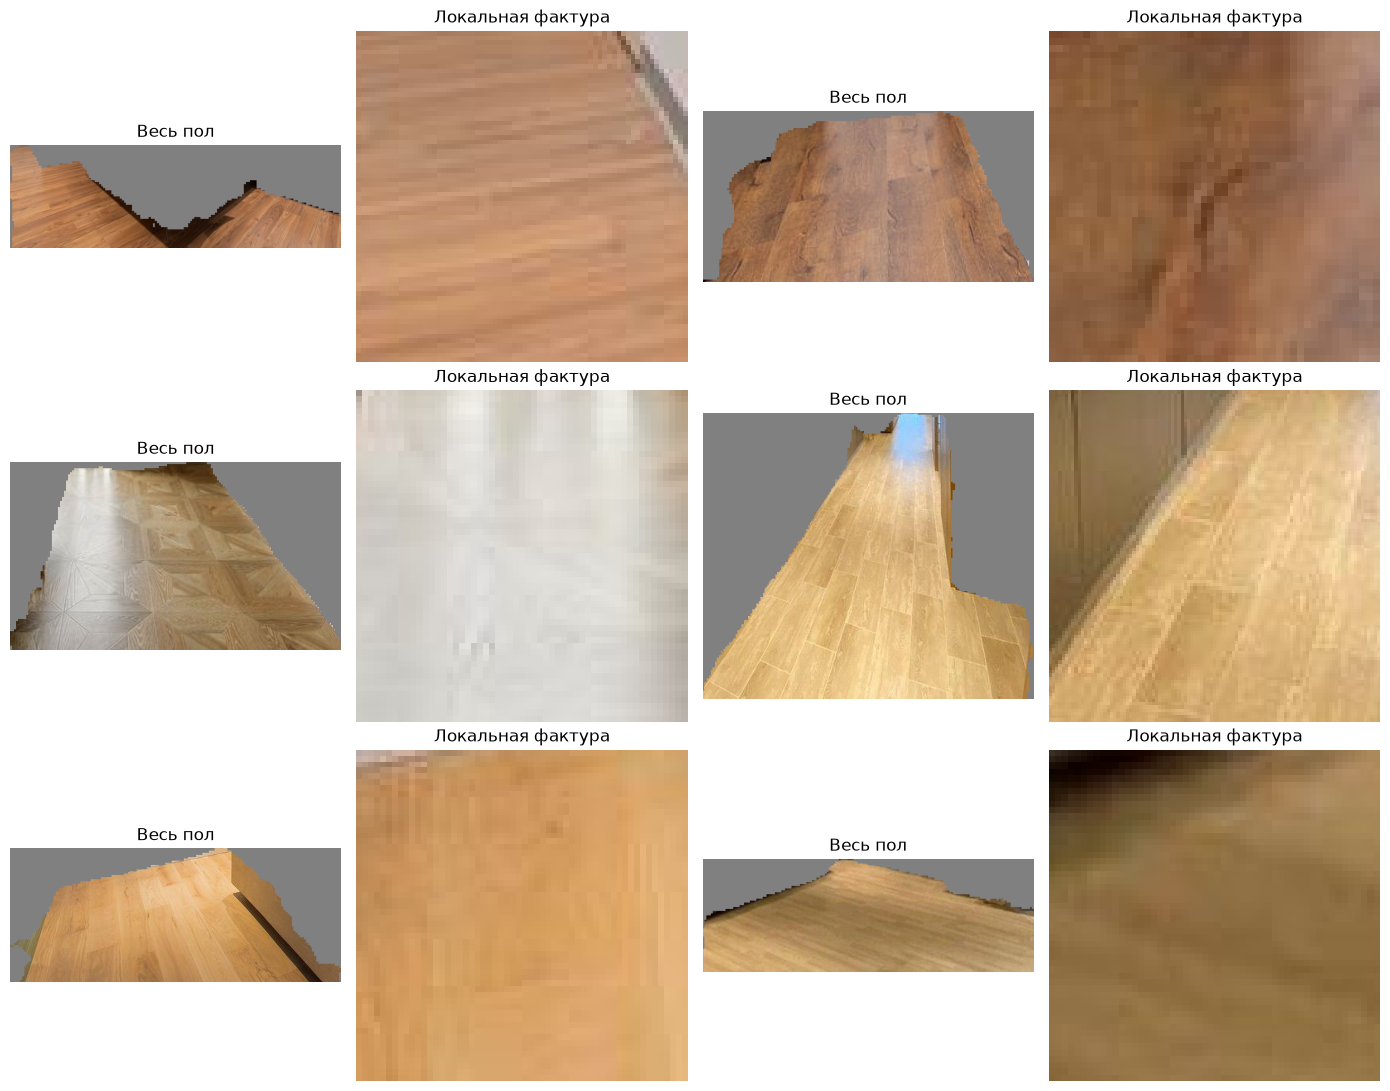

In [4]:
PREVIEW_CLASS='wood_flooring'
preview=view_manifest[(view_manifest.label==PREVIEW_CLASS)&(view_manifest.split=='train')].head(6)
fig,axes=plt.subplots(3,4,figsize=(14,11));axes=axes.flatten()
for ax in axes:ax.axis('off')
for i,row in enumerate(preview.to_dict('records')):
    global_image=render_floor_view(row['path'],row);local_image=render_local_views(row['path'],row)[0]
    axes[2*i].imshow(global_image);axes[2*i].set_title('Весь пол');axes[2*i].axis('off')
    axes[2*i+1].imshow(local_image);axes[2*i+1].set_title('Локальная фактура');axes[2*i+1].axis('off')
plt.tight_layout();plt.show()


## 4. DINOv2 и классификатор покрытия пола

DINOv2 остаётся замороженным. Глобальный признак поверхности, attention-представление девяти участков и max-pooled представление объединяются классификатором пяти покрытий.


In [5]:
DINO_NAME='facebook/dinov2-small'
DINO_BATCH_VIEWS=4
GLOBAL_DINO_SIZE=448
LOCAL_DINO_SIZE=224
dino_processor=AutoImageProcessor.from_pretrained(DINO_NAME)
dino_model=AutoModel.from_pretrained(DINO_NAME).to(device).eval()
for parameter in dino_model.parameters():parameter.requires_grad=False

records=view_manifest.to_dict('records');global_batches=[];local_batches=[]
with torch.no_grad():
    for start in range(0,len(records),DINO_BATCH_VIEWS):
        batch_rows=records[start:start+DINO_BATCH_VIEWS]
        global_images=[render_floor_view(row['path'],row) for row in batch_rows]
        local_images=[image for row in batch_rows for image in render_local_views(row['path'],row)]
        global_inputs=dino_processor(images=global_images,return_tensors='pt',do_resize=True,size={'height':GLOBAL_DINO_SIZE,'width':GLOBAL_DINO_SIZE},do_center_crop=False).to(device)
        local_inputs=dino_processor(images=local_images,return_tensors='pt',do_resize=True,size={'height':LOCAL_DINO_SIZE,'width':LOCAL_DINO_SIZE},do_center_crop=False).to(device)
        global_cls=dino_model(**global_inputs).last_hidden_state[:,0].cpu()
        local_cls=dino_model(**local_inputs).last_hidden_state[:,0].cpu().reshape(len(batch_rows),LOCAL_VIEWS_PER_FLOOR,-1)
        global_batches.append(global_cls);local_batches.append(local_cls)
        if start%40==0:print(f'DINOv2: {min(start+len(batch_rows),len(records))}/{len(records)} областей пола',flush=True)

global_features=torch.cat(global_batches);local_features=torch.cat(local_batches)
labels=torch.tensor([classes.index(row['label']) for row in records],dtype=torch.long)
split_names=np.array([row['split'] for row in records]);source_ids=np.array([row['source_id'] for row in records]);view_ids=np.array([row['view_id'] for row in records])
np.savez_compressed(OUT/'dinov2_embeddings.npz',global_features=global_features.numpy(),local_features=local_features.numpy(),labels=labels.numpy(),splits=split_names,source_ids=source_ids,view_ids=view_ids)
print('Global:',tuple(global_features.shape),'Local:',tuple(local_features.shape))

class EmbeddingDataset(Dataset):
    def __init__(self,indices):self.indices=np.asarray(indices)
    def __len__(self):return len(self.indices)
    def __getitem__(self,index):
        real=int(self.indices[index]);return global_features[real],local_features[real],labels[real],source_ids[real],view_ids[real]

indices={split:np.where(split_names==split)[0] for split in ['train','val','test']}
train_labels=labels[indices['train']].numpy();train_counts=np.bincount(train_labels,minlength=len(classes));train_weights=1.0/train_counts[train_labels]
train_sampler=WeightedRandomSampler(torch.as_tensor(train_weights,dtype=torch.double),len(train_weights),replacement=True)
print('Train views before balancing:',dict(zip(classes,train_counts.tolist())))
loaders={
    'train':DataLoader(EmbeddingDataset(indices['train']),batch_size=32,sampler=train_sampler,num_workers=0),
    'val':DataLoader(EmbeddingDataset(indices['val']),batch_size=64,shuffle=False,num_workers=0),
    'test':DataLoader(EmbeddingDataset(indices['test']),batch_size=64,shuffle=False,num_workers=0),
}

class FloorClassifier(torch.nn.Module):
    def __init__(self,feature_dim,num_classes):
        super().__init__()
        self.attention=torch.nn.Sequential(torch.nn.Linear(feature_dim,128),torch.nn.Tanh(),torch.nn.Linear(128,1))
        fused_dim=feature_dim*3
        self.shared=torch.nn.Sequential(torch.nn.LayerNorm(fused_dim),torch.nn.Linear(fused_dim,384),torch.nn.GELU(),torch.nn.Dropout(.30))
        self.class_head=torch.nn.Linear(384,num_classes)
    def forward(self,global_embedding,local_embeddings):
        attention_weights=self.attention(local_embeddings).squeeze(-1).softmax(1)
        attended=(local_embeddings*attention_weights.unsqueeze(-1)).sum(1)
        maximum=local_embeddings.max(1).values
        shared=self.shared(torch.cat([global_embedding,attended,maximum],dim=1))
        return self.class_head(shared),attention_weights

model=FloorClassifier(global_features.shape[1],len(classes)).to(device)
criterion=torch.nn.CrossEntropyLoss()
optimizer=torch.optim.AdamW(model.parameters(),lr=3e-4,weight_decay=1e-3)

del dino_model
if device.type=='mps':torch.mps.empty_cache()


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2: 4/560 областей пола
DINOv2: 44/560 областей пола
DINOv2: 84/560 областей пола
DINOv2: 124/560 областей пола
DINOv2: 164/560 областей пола
DINOv2: 204/560 областей пола
DINOv2: 244/560 областей пола
DINOv2: 284/560 областей пола
DINOv2: 324/560 областей пола
DINOv2: 364/560 областей пола
DINOv2: 404/560 областей пола
DINOv2: 444/560 областей пола
DINOv2: 484/560 областей пола
DINOv2: 524/560 областей пола
Global: (560, 384) Local: (560, 9, 384)
Train views before balancing: {'bare_unfinished_floor': 83, 'carpet': 76, 'tile_or_stone': 81, 'vinyl_or_linoleum': 75, 'wood_flooring': 76}


In [6]:
def run_epoch(loader,training=False):
    model.train(training);loss_sum=correct=count=0;all_labels=[];all_predictions=[]
    for global_batch,local_batch,batch_labels,_,_ in loader:
        global_batch,local_batch,batch_labels=global_batch.to(device),local_batch.to(device),batch_labels.to(device)
        if training:optimizer.zero_grad()
        with torch.set_grad_enabled(training):
            class_logits,_=model(global_batch,local_batch)
            loss=criterion(class_logits,batch_labels)
            if training:loss.backward();optimizer.step()
        predictions=class_logits.argmax(1)
        loss_sum+=loss.item()*len(batch_labels);correct+=(predictions==batch_labels).sum().item();count+=len(batch_labels)
        all_labels.extend(batch_labels.detach().cpu().tolist());all_predictions.extend(predictions.detach().cpu().tolist())
    return loss_sum/count,correct/count,f1_score(all_labels,all_predictions,average='macro',zero_division=0)

best_f1=-1.0;stale=0;history=[]
for epoch in range(60):
    train_loss,train_acc,train_f1=run_epoch(loaders['train'],True);val_loss,val_acc,val_f1=run_epoch(loaders['val'])
    row={'epoch':epoch+1,'train_loss':train_loss,'train_acc':train_acc,'train_macro_f1':train_f1,'val_loss':val_loss,'val_acc':val_acc,'val_macro_f1':val_f1};history.append(row)
    print(f"{epoch+1}/60 train={train_acc:.3f} train_f1={train_f1:.3f} val={val_acc:.3f} val_f1={val_f1:.3f} val_loss={val_loss:.3f}")
    checkpoint={'state_dict':{k:v.detach().cpu().clone() for k,v in model.state_dict().items()},'classes':classes,'architecture':'dinov2_floor_attention','feature_size':global_features.shape[1],'local_views':LOCAL_VIEWS_PER_FLOOR,'task':'floor_classifier','epoch':epoch+1,'val_loss':val_loss,'val_acc':val_acc,'val_macro_f1':val_f1}
    if val_f1>best_f1+1e-4:best_f1=val_f1;stale=0;torch.save(checkpoint,OUT/'best.pt')
    else:stale+=1
    pd.DataFrame(history).to_csv(OUT/'history.csv',index=False)
    if stale>=10:print('Ранняя остановка по val_macro_f1');break


1/60 train=0.621 train_f1=0.617 val=0.721 val_f1=0.671 val_loss=0.749
2/60 train=0.836 train_f1=0.833 val=0.779 val_f1=0.728 val_loss=0.554
3/60 train=0.890 train_f1=0.892 val=0.814 val_f1=0.788 val_loss=0.531
4/60 train=0.936 train_f1=0.938 val=0.837 val_f1=0.814 val_loss=0.441
5/60 train=0.939 train_f1=0.938 val=0.860 val_f1=0.829 val_loss=0.449
6/60 train=0.985 train_f1=0.985 val=0.884 val_f1=0.862 val_loss=0.408
7/60 train=0.974 train_f1=0.974 val=0.860 val_f1=0.840 val_loss=0.404
8/60 train=0.982 train_f1=0.982 val=0.884 val_f1=0.866 val_loss=0.381
9/60 train=0.992 train_f1=0.992 val=0.884 val_f1=0.865 val_loss=0.379
10/60 train=0.985 train_f1=0.984 val=0.860 val_f1=0.842 val_loss=0.390
11/60 train=0.995 train_f1=0.994 val=0.849 val_f1=0.831 val_loss=0.387
12/60 train=0.997 train_f1=0.997 val=0.884 val_f1=0.864 val_loss=0.406
13/60 train=0.992 train_f1=0.992 val=0.849 val_f1=0.831 val_loss=0.431
14/60 train=0.995 train_f1=0.995 val=0.849 val_f1=0.826 val_loss=0.415
15/60 train=0.9

## 5. Оценка модели пола

Метрики считаются отдельно по найденным областям пола и по исходным фотографиям. Лучший чекпоинт выбирается по validation macro-F1.


In [7]:
checkpoint=torch.load(OUT/'best.pt',map_location='cpu',weights_only=True);model.load_state_dict(checkpoint['state_dict']);model.eval()
view_truth=[];view_pred=[];prediction_rows=[]
with torch.no_grad():
    for global_batch,local_batch,batch_labels,batch_source_ids,batch_view_ids in loaders['test']:
        class_logits,_=model(global_batch.to(device),local_batch.to(device));probabilities=class_logits.softmax(1).cpu();predictions=probabilities.argmax(1)
        view_truth.extend(batch_labels.tolist());view_pred.extend(predictions.tolist())
        for source_id,view_id,label,prob in zip(batch_source_ids,batch_view_ids,batch_labels.tolist(),probabilities):prediction_rows.append({'source_id':source_id,'view_id':view_id,'true_index':label,'probabilities':prob.numpy()})
print('FLOOR REGION LEVEL')
view_report=classification_report(view_truth,view_pred,labels=list(range(len(classes))),target_names=classes,zero_division=0);print(view_report)
source_truth=[];source_pred=[]
for source_id,group in pd.DataFrame(prediction_rows).groupby('source_id'):
    probs=np.stack(group.probabilities).mean(0);source_truth.append(int(group.true_index.iloc[0]));source_pred.append(int(probs.argmax()))
print('SOURCE IMAGE LEVEL')
source_report=classification_report(source_truth,source_pred,labels=list(range(len(classes))),target_names=classes,zero_division=0);print(source_report)
summary={'region_accuracy':accuracy_score(view_truth,view_pred),'region_macro_f1':f1_score(view_truth,view_pred,average='macro',zero_division=0),'source_accuracy':accuracy_score(source_truth,source_pred),'source_macro_f1':f1_score(source_truth,source_pred,average='macro',zero_division=0),'test_regions':len(view_truth),'test_sources':len(source_truth),'best_epoch':checkpoint['epoch'],'best_val_loss':checkpoint['val_loss'],'best_val_acc':checkpoint['val_acc'],'best_val_macro_f1':checkpoint['val_macro_f1']}
(OUT/'classification_report_regions.txt').write_text(view_report);(OUT/'classification_report_sources.txt').write_text(source_report);(OUT/'summary.json').write_text(json.dumps(summary,indent=2));print(summary)


FLOOR REGION LEVEL
                       precision    recall  f1-score   support

bare_unfinished_floor       1.00      1.00      1.00        22
               carpet       0.93      0.88      0.90        16
        tile_or_stone       0.93      0.88      0.90        16
    vinyl_or_linoleum       0.69      0.69      0.69        13
        wood_flooring       0.67      0.75      0.71        16

             accuracy                           0.86        83
            macro avg       0.85      0.84      0.84        83
         weighted avg       0.86      0.86      0.86        83

SOURCE IMAGE LEVEL
                       precision    recall  f1-score   support

bare_unfinished_floor       1.00      1.00      1.00        22
               carpet       0.93      0.87      0.90        15
        tile_or_stone       0.93      0.93      0.93        15
    vinyl_or_linoleum       0.69      0.69      0.69        13
        wood_flooring       0.71      0.75      0.73        16

            

## 6. Применение к новому фото

Функция возвращает найденные области покрытия, источник маски (`floor` или `rug`), вероятности пяти классов и `uncertain` при низкой уверенности. Видимый пол имеет приоритет над переносным ковром.


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

{
  "image": "/Users/himynameisartem/Documents/Development/ML/Renovation_calculator_CV/data/dataset/test/630-2_1680531410.jpg",
  "floors": [
    {
      "x0": 37,
      "y0": 426,
      "x1": 628,
      "y1": 628,
      "floor_coverage": 0.6236618585716439,
      "mask_source": "floor",
      "mask_h": 55,
      "mask_w": 160,
      "material": "bare_unfinished_floor",
      "top_candidate": "bare_unfinished_floor",
      "confidence": 0.941,
      "probabilities": {
        "bare_unfinished_floor": 0.941,
        "carpet": 0.054,
        "tile_or_stone": 0.002,
        "vinyl_or_linoleum": 0.003,
        "wood_flooring": 0.001
      },
      "local_attention": [
        0.147,
        0.063,
        0.194,
        0.123,
        0.07,
        0.085,
        0.088,
        0.206,
        0.023
      ]
    }
  ]
}


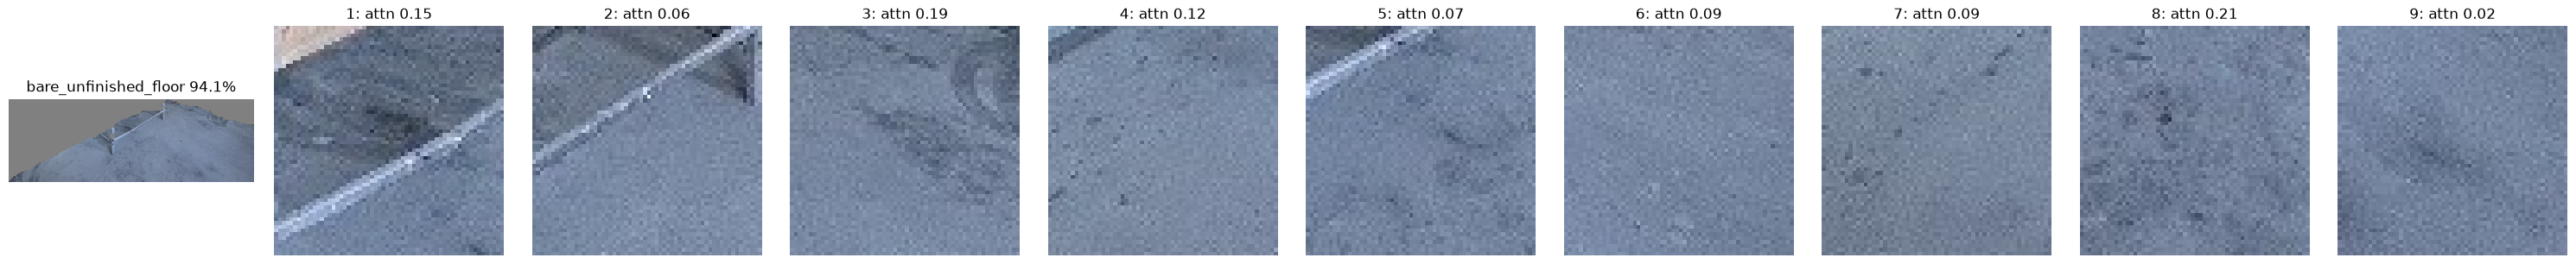

In [12]:
MIN_CONFIDENCE=.40
inference_processor=AutoImageProcessor.from_pretrained(segmenter_name);inference_segmenter=SegformerForSemanticSegmentation.from_pretrained(segmenter_name).to(device).eval()
inference_floor_id=next(int(k) for k,v in inference_segmenter.config.id2label.items() if v=='floor');inference_rug_id=next(int(k) for k,v in inference_segmenter.config.id2label.items() if v=='rug')
processor,segmenter,floor_id,rug_id=inference_processor,inference_segmenter,inference_floor_id,inference_rug_id
dino_processor=AutoImageProcessor.from_pretrained(DINO_NAME);dino_model=AutoModel.from_pretrained(DINO_NAME).to(device).eval()

@torch.no_grad()
def predict_floor_image(image_path):
    views=find_floor_views(image_path)
    if not views:return [],[]
    global_images=[render_floor_view(image_path,view) for view in views];local_images=[image for view in views for image in render_local_views(image_path,view)]
    global_inputs=dino_processor(images=global_images,return_tensors='pt',do_resize=True,size={'height':GLOBAL_DINO_SIZE,'width':GLOBAL_DINO_SIZE},do_center_crop=False).to(device)
    local_inputs=dino_processor(images=local_images,return_tensors='pt',do_resize=True,size={'height':LOCAL_DINO_SIZE,'width':LOCAL_DINO_SIZE},do_center_crop=False).to(device)
    global_embedding=dino_model(**global_inputs).last_hidden_state[:,0]
    local_embedding=dino_model(**local_inputs).last_hidden_state[:,0].reshape(len(views),LOCAL_VIEWS_PER_FLOOR,-1)
    class_logits,attention=model(global_embedding,local_embedding);probs=class_logits.softmax(1).cpu().numpy();attention=attention.cpu().numpy()
    predictions=[]
    for view,prob,weights in zip(views,probs,attention):
        index=int(prob.argmax());confidence=float(prob[index]);public_view={k:v for k,v in view.items() if k not in {'mask_data','local_boxes'}}
        predictions.append({**public_view,'material':classes[index] if confidence>=MIN_CONFIDENCE else 'uncertain','top_candidate':classes[index],'confidence':round(confidence,3),'probabilities':{name:round(float(value),3) for name,value in zip(classes,prob)},'local_attention':[round(float(value),3) for value in weights]})
    return views,predictions

external_candidates=sorted(path for path in (PROJECT/'data/dataset/test').iterdir() if path.is_file() and path.suffix.lower() in extensions)
IMAGE_PATH=external_candidates[0]
views,predictions=predict_floor_image(IMAGE_PATH)
print(json.dumps({'image':str(IMAGE_PATH),'floors':predictions},ensure_ascii=False,indent=2))
if views:
    fig,axes=plt.subplots(len(views),1+LOCAL_VIEWS_PER_FLOOR,figsize=(3*(1+LOCAL_VIEWS_PER_FLOOR),3*len(views)))
    if len(views)==1:axes=np.array([axes])
    for row,(view,prediction) in enumerate(zip(views,predictions)):
        axes[row,0].imshow(render_floor_view(IMAGE_PATH,view));axes[row,0].set_title(f"{prediction['top_candidate']} {prediction['confidence']:.1%}");axes[row,0].axis('off')
        for column,(image,weight) in enumerate(zip(render_local_views(IMAGE_PATH,view),prediction['local_attention']),start=1):axes[row,column].imshow(image);axes[row,column].set_title(f'{column}: attn {weight:.2f}');axes[row,column].axis('off')
    plt.tight_layout();plt.show()


## 7. Внешняя проверка на папке `data/dataset/test`

Эти фотографии не участвуют в обучении. Для каждого изображения показывается исходный кадр и найденные области пола с предсказаниями.


,image,floor,prediction,top_candidate,confidence
0,630-2_1680531410.jpg,1,bare_unfinished_floor,bare_unfinished_floor,94.1%
1,7a3e3f0d53e7f120ecd9e1486819de8f41689.jpg,1,bare_unfinished_floor,bare_unfinished_floor,83.4%
2,86cd0c3b08816019855db1127e03da61.jpg,1,bare_unfinished_floor,bare_unfinished_floor,94.1%
3,chernovaya-otdelka.jpg,1,vinyl_or_linoleum,vinyl_or_linoleum,46.8%
4,images-12.jpeg,1,wood_flooring,wood_flooring,97.3%
5,images-13.jpeg,1,wood_flooring,wood_flooring,99.1%
6,images-2.jpeg,1,bare_unfinished_floor,bare_unfinished_floor,83.6%
7,images-4.jpeg,1,wood_flooring,wood_flooring,69.4%
8,images-5.jpeg,1,wood_flooring,wood_flooring,43.1%
9,images-6.jpeg,1,wood_flooring,wood_flooring,98.4%


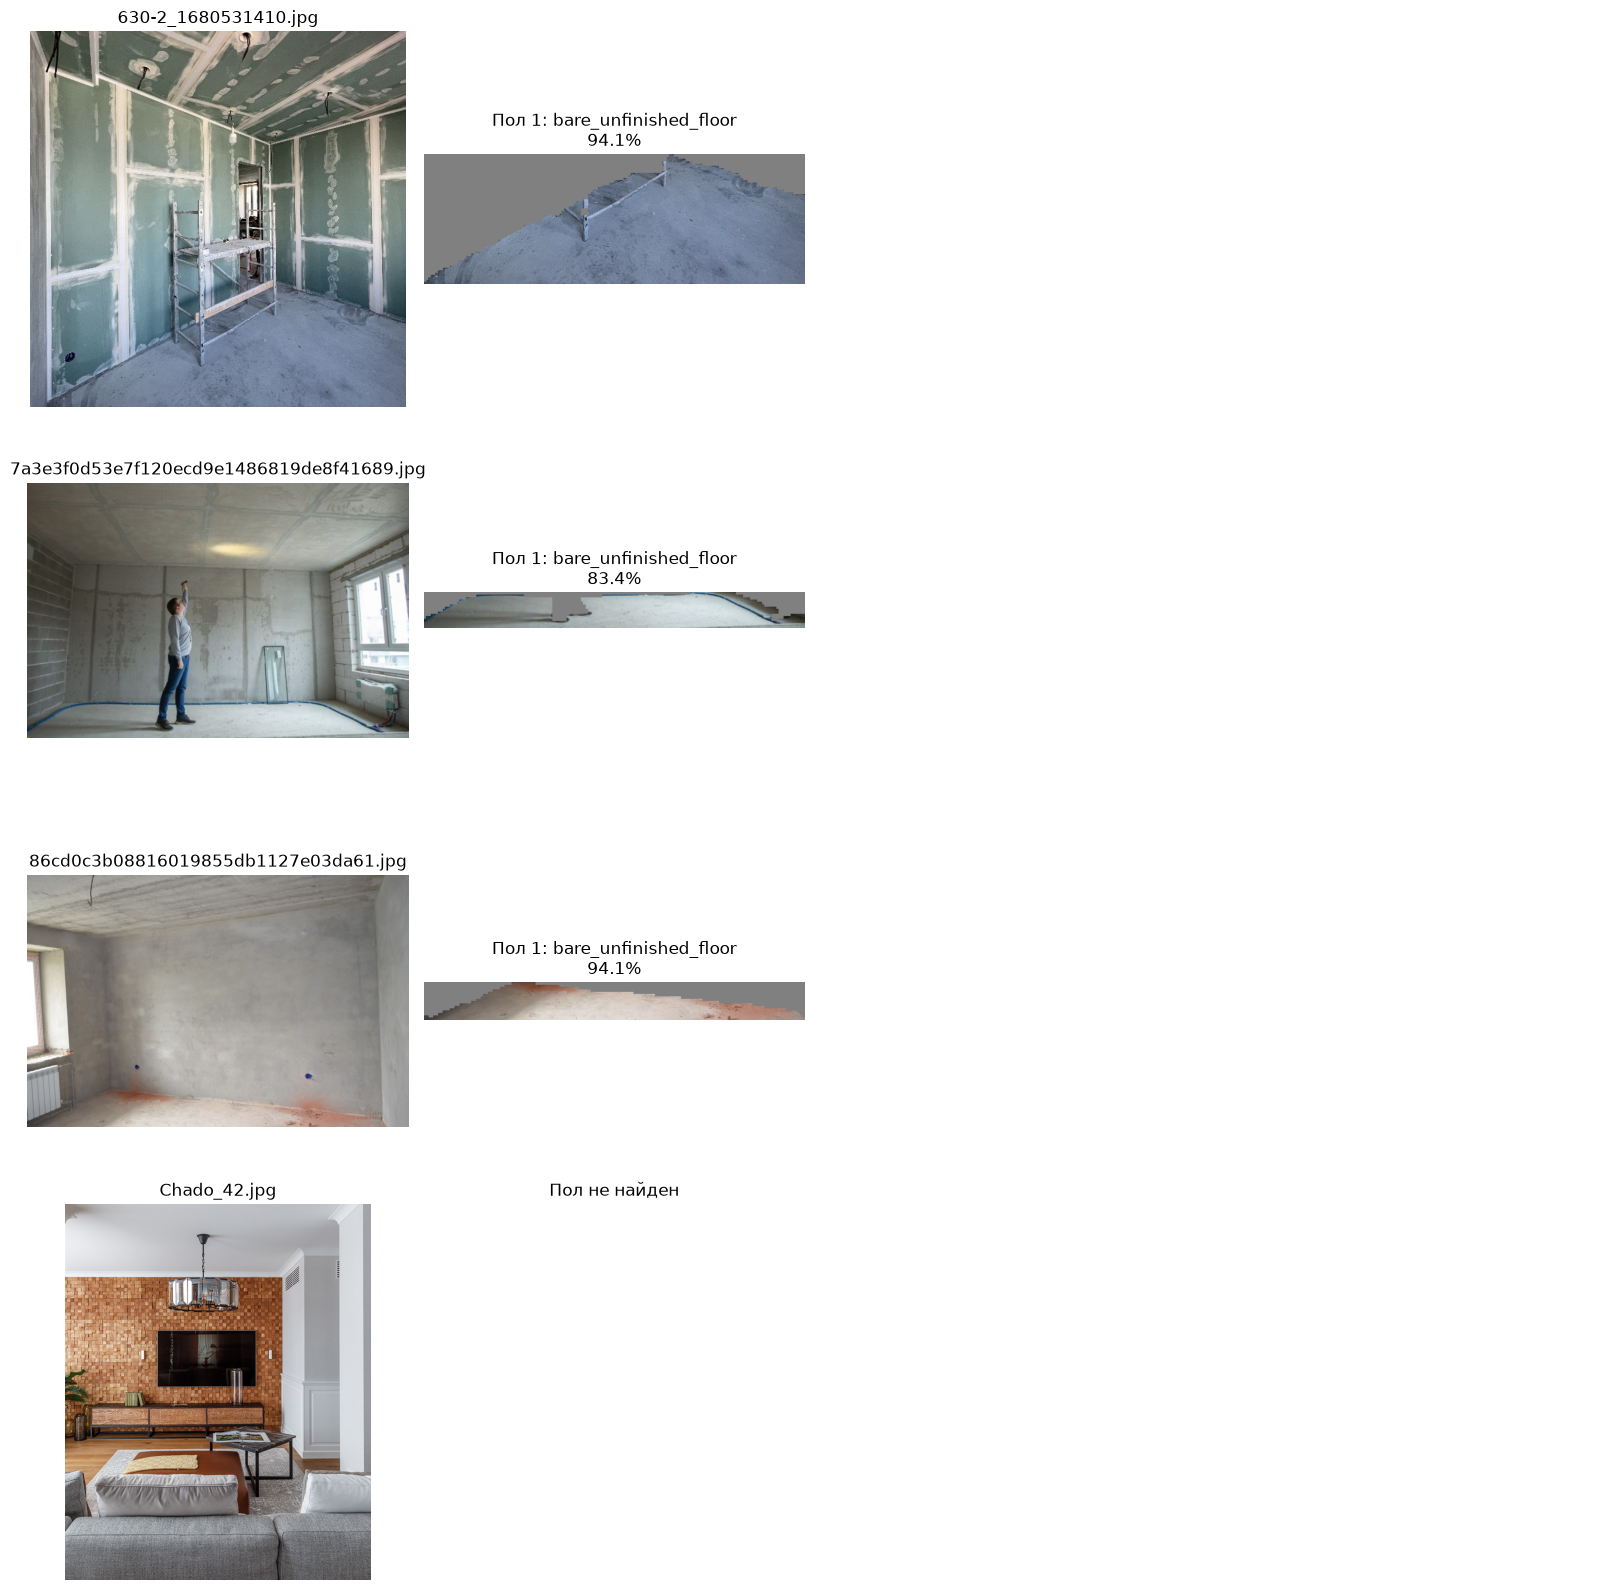

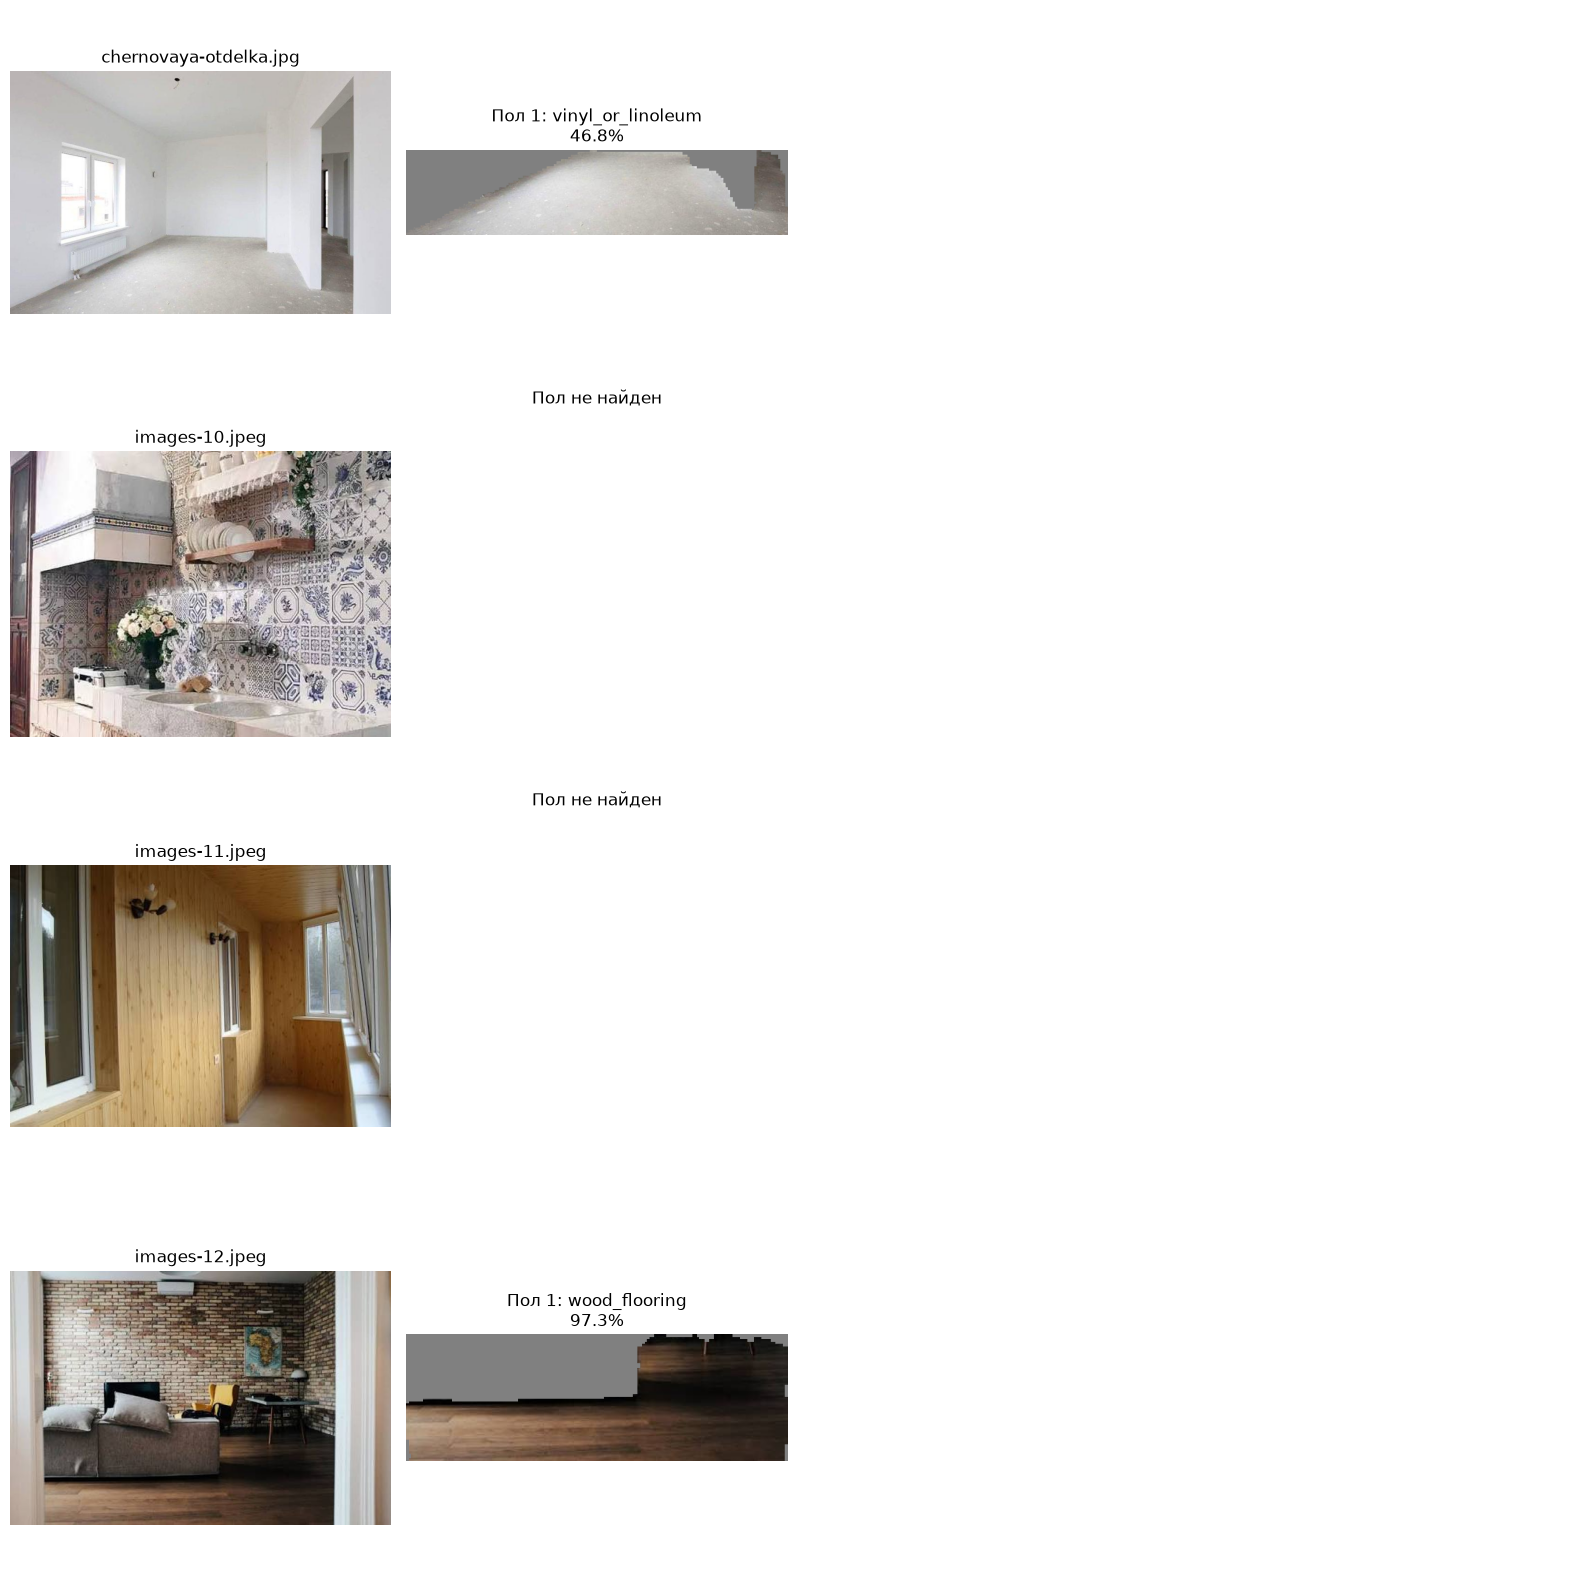

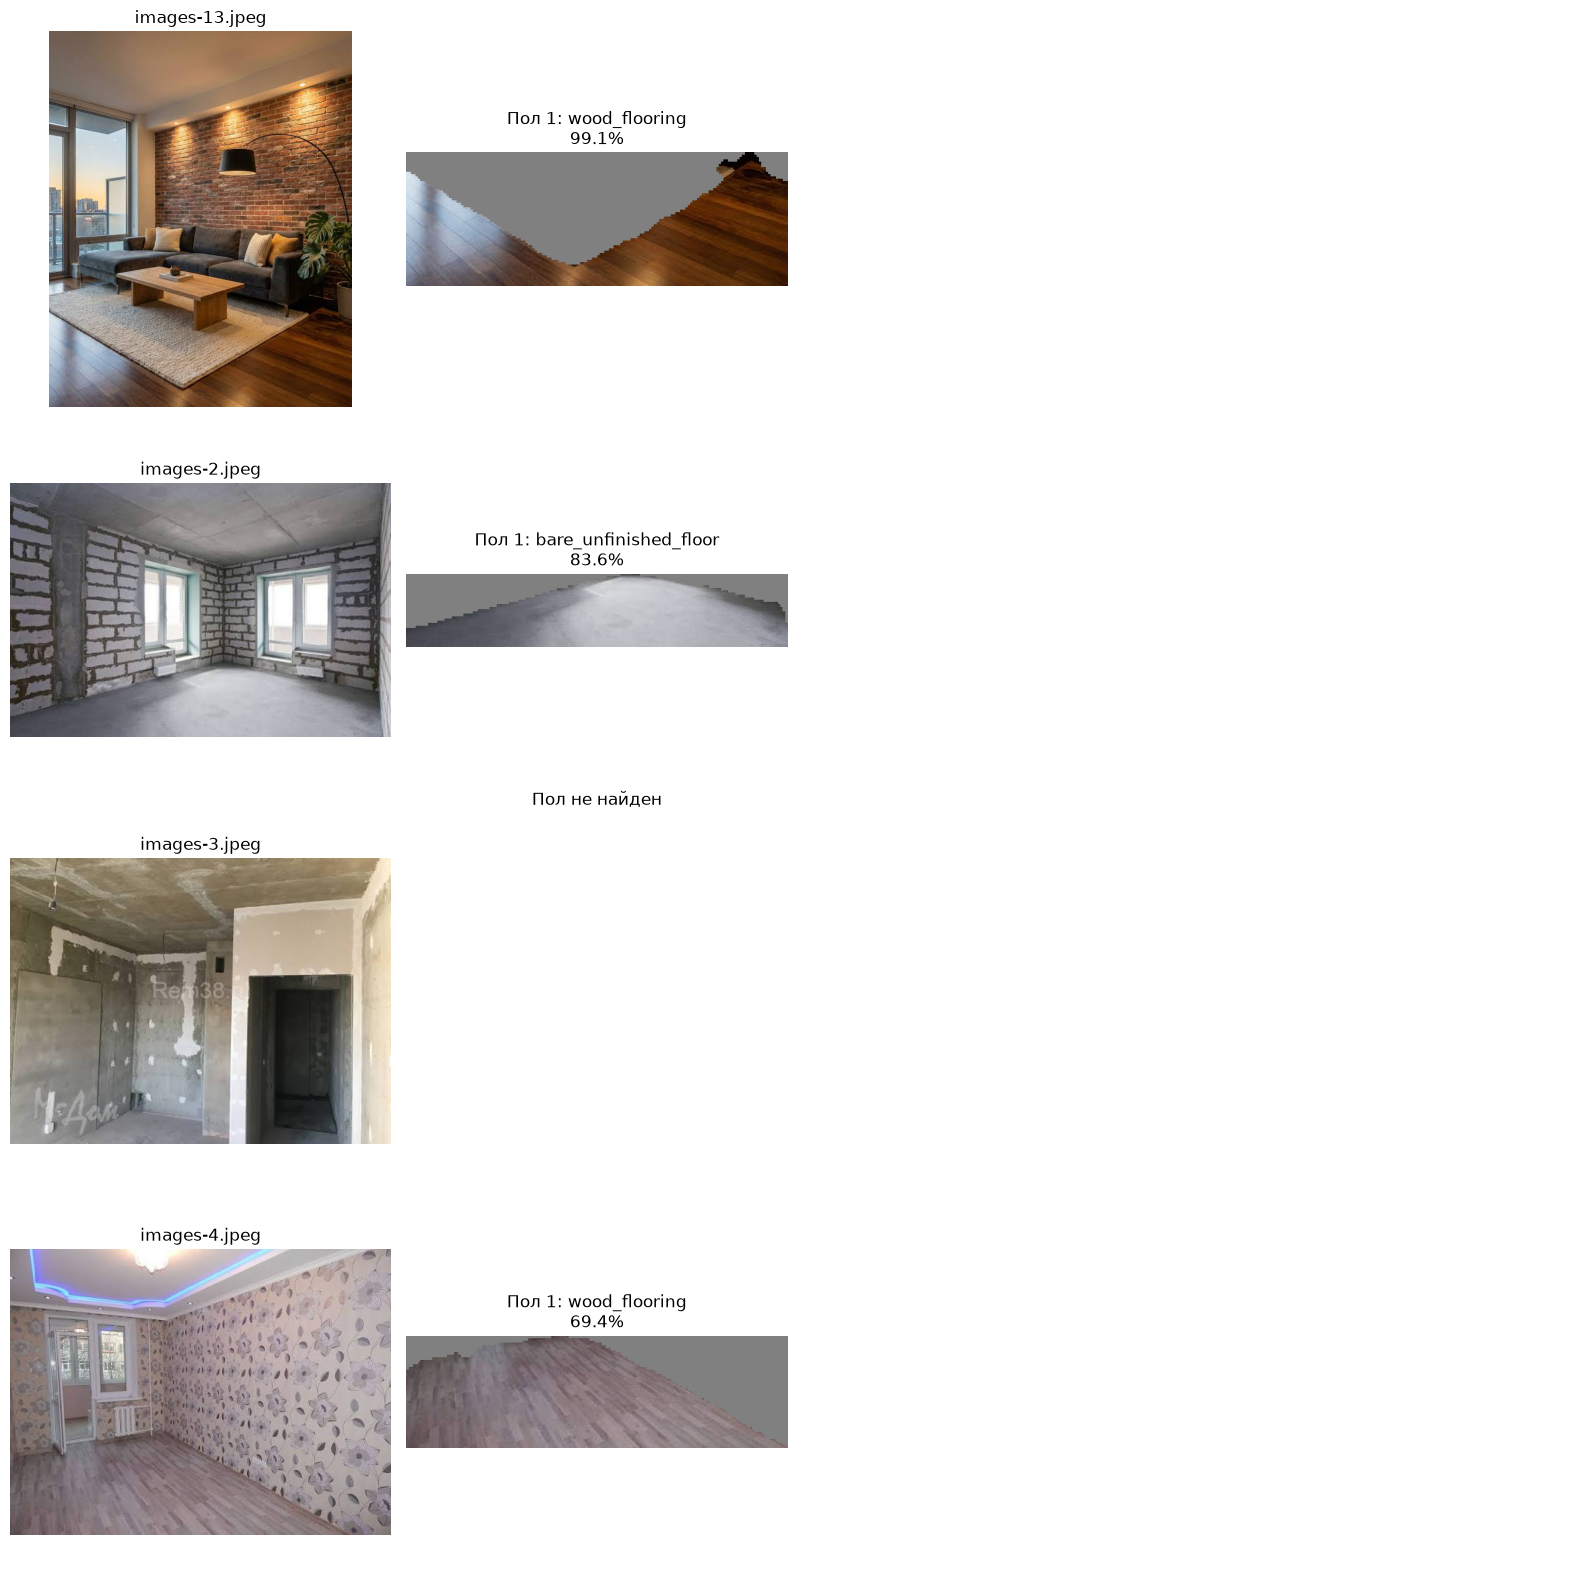

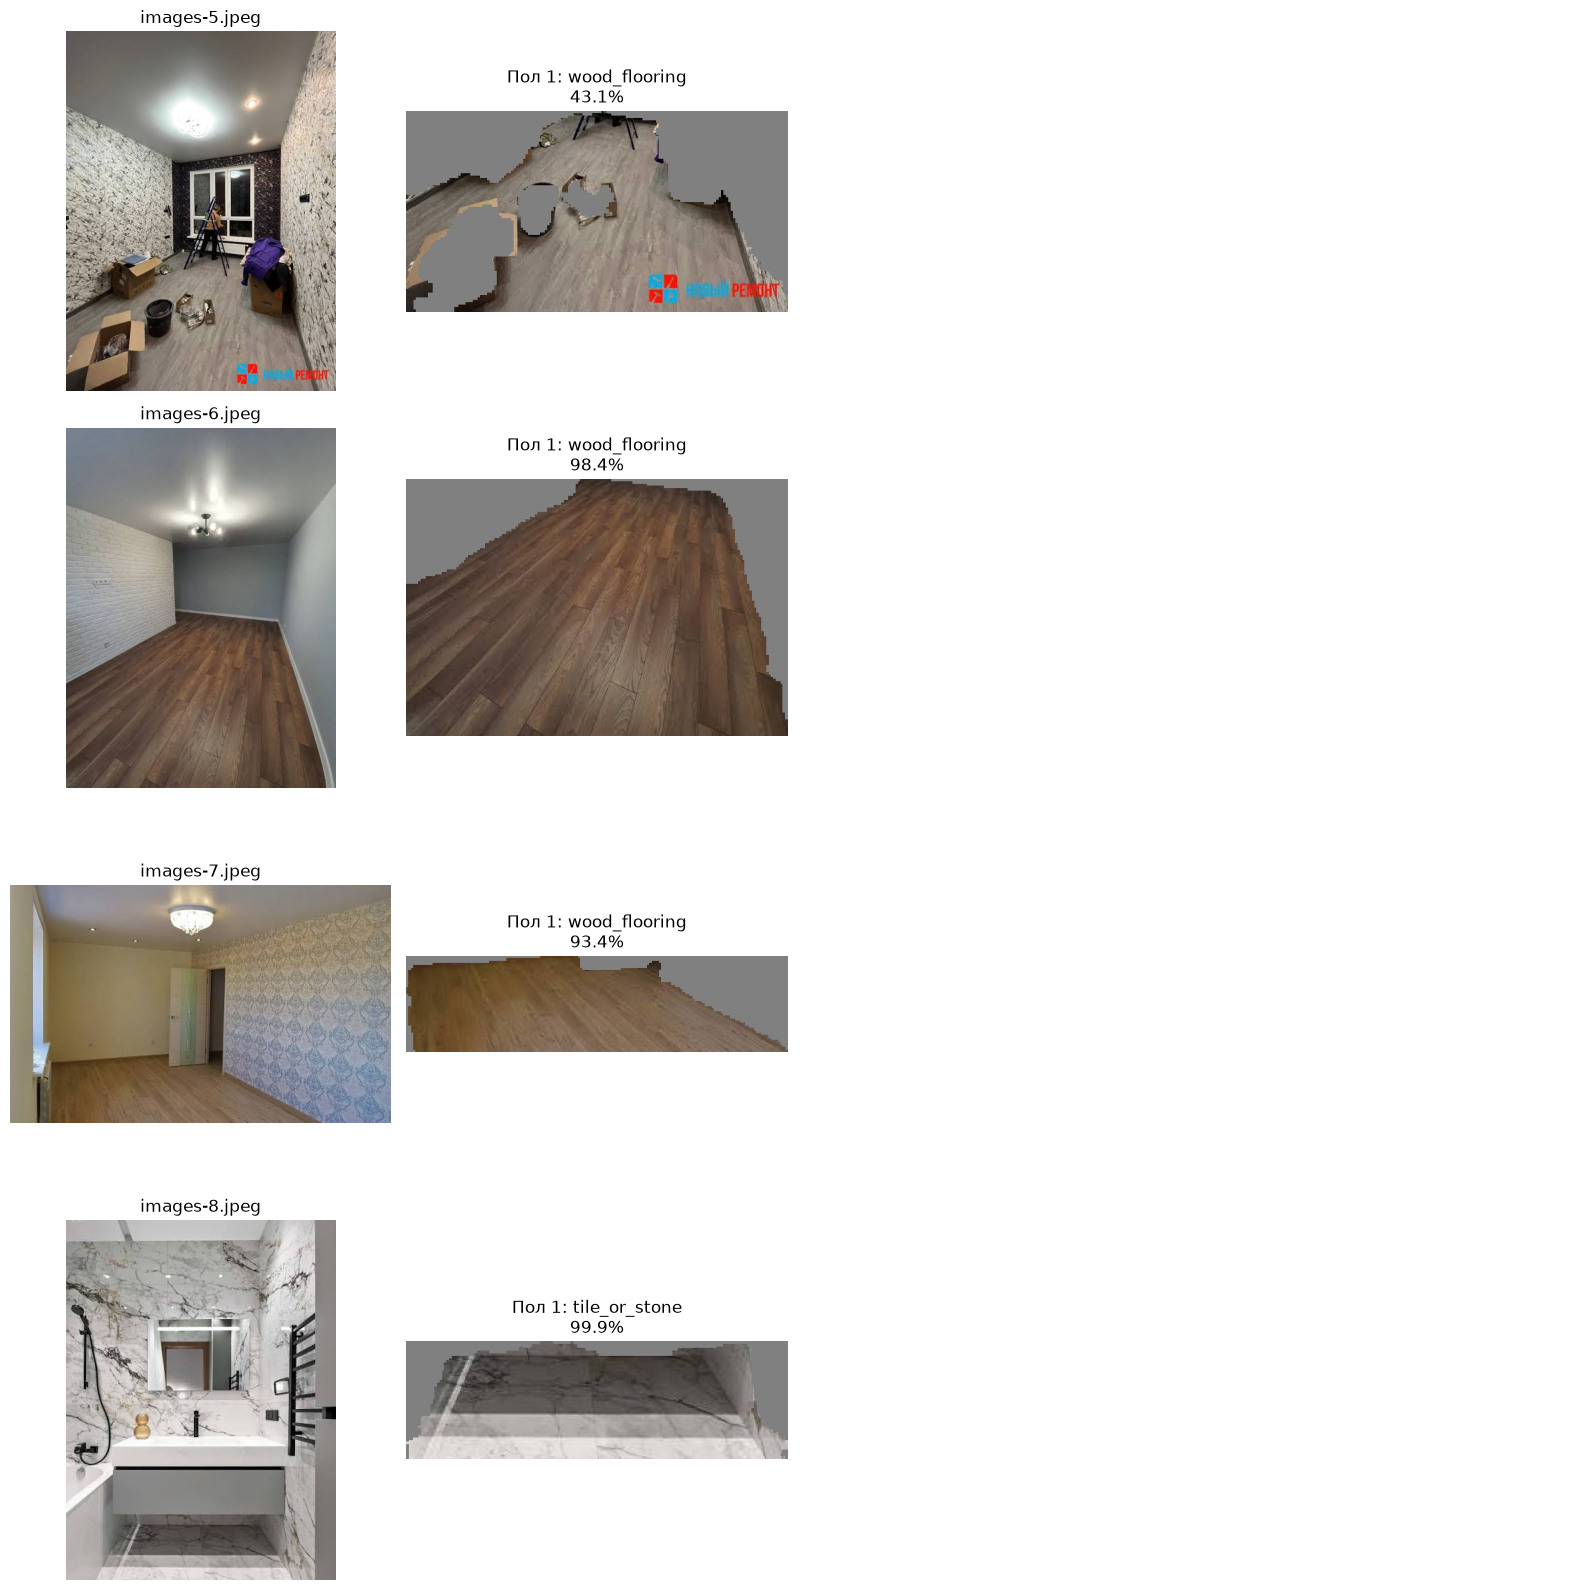

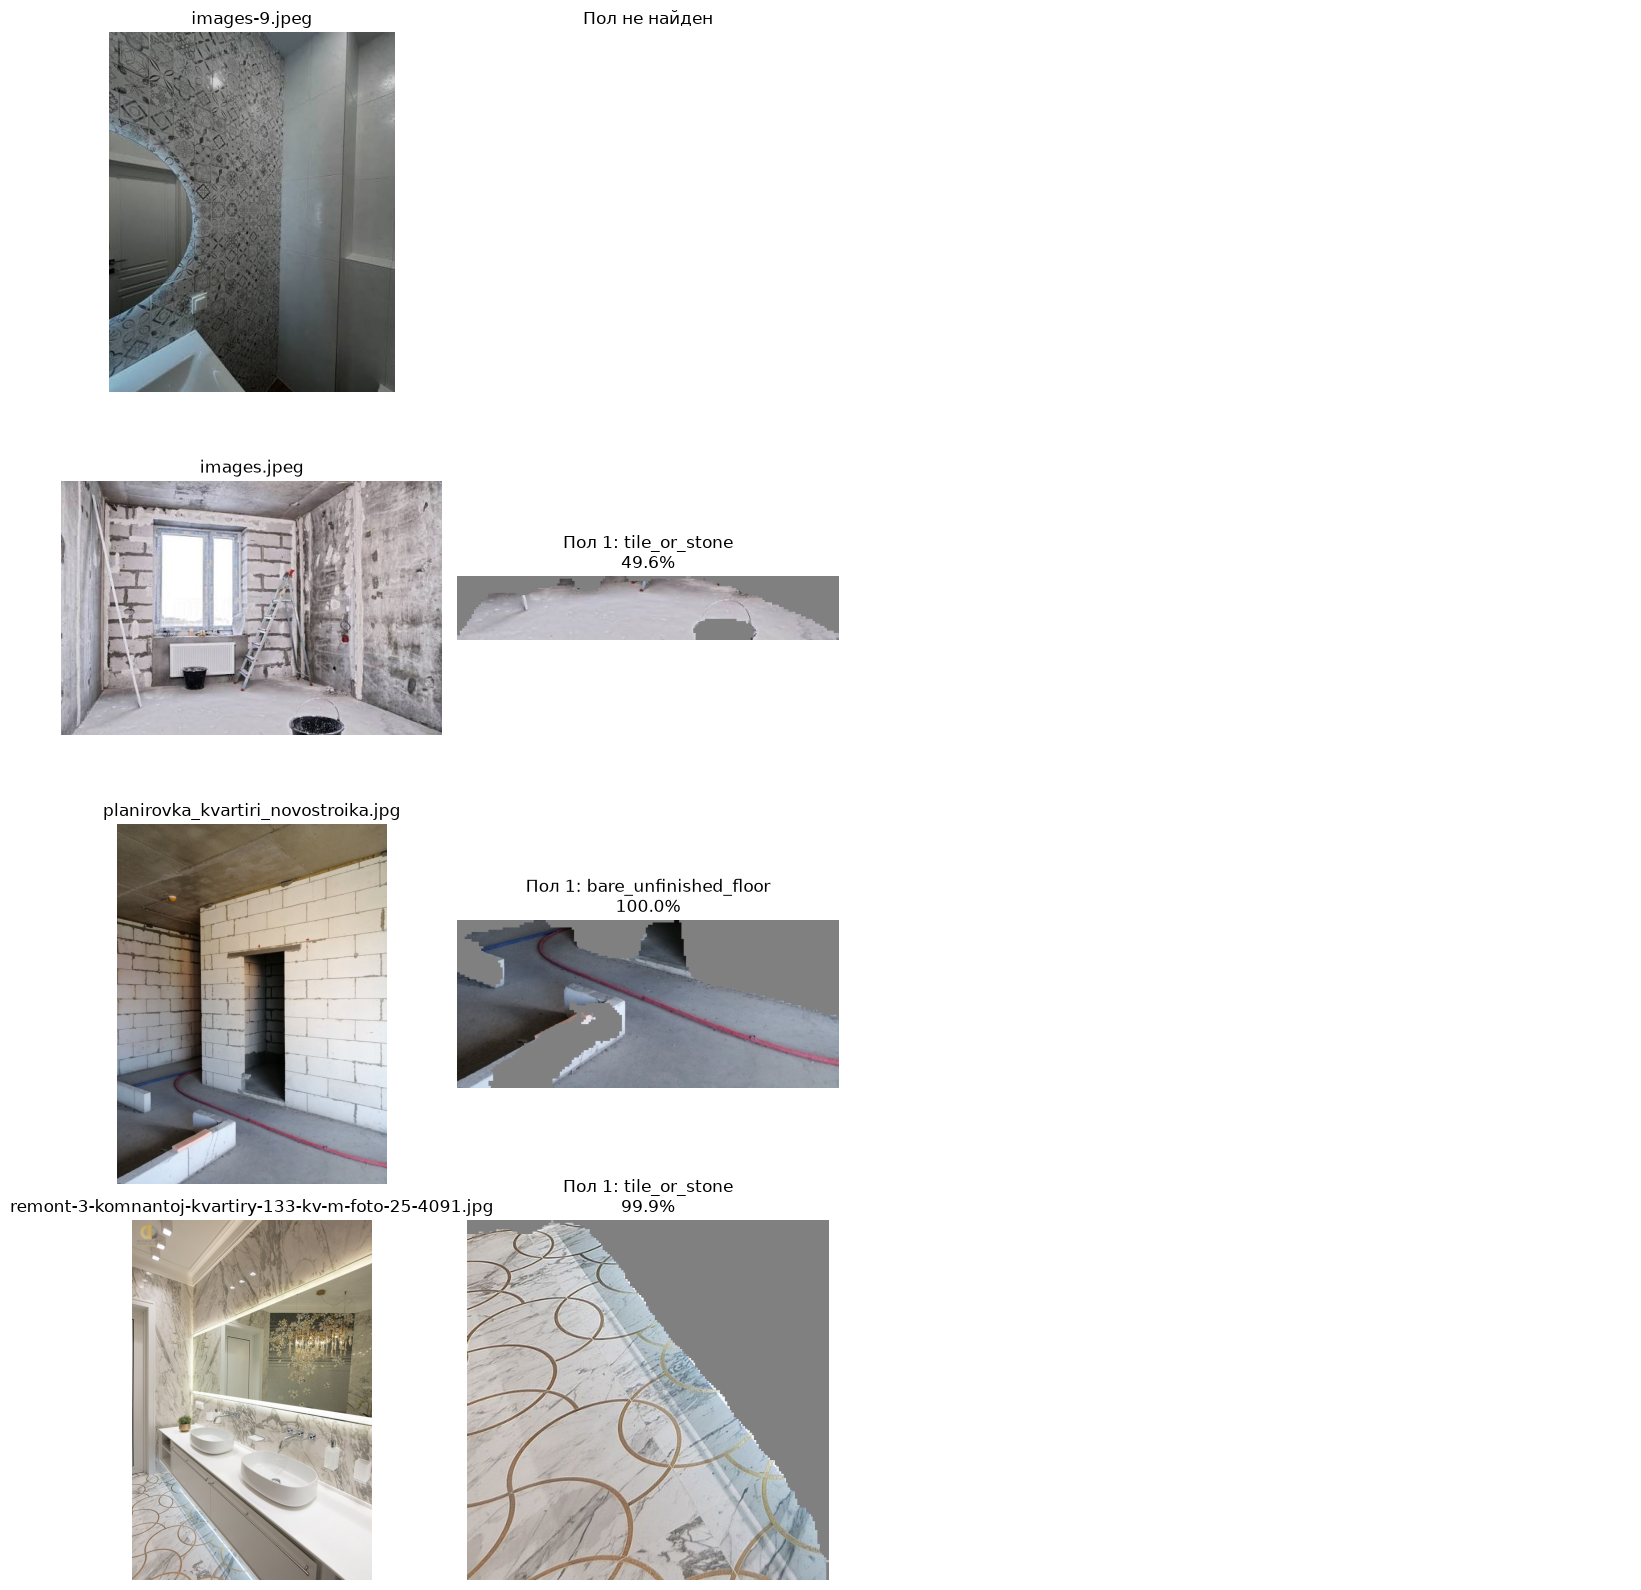

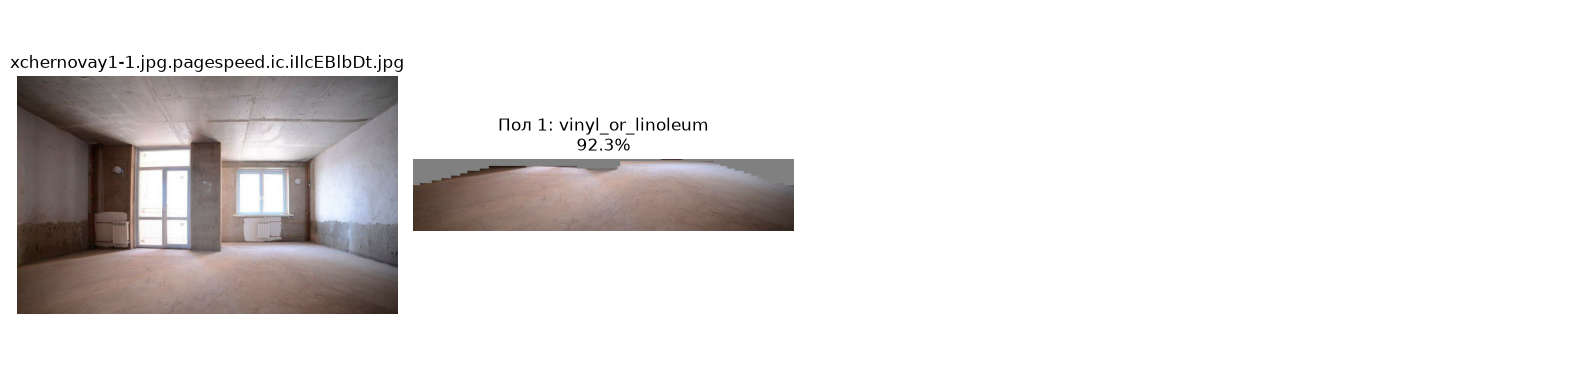

Проверено изображений: 21; найдено областей пола: 16


In [13]:
TEST_DIR=PROJECT/'data/dataset/test'
test_paths=sorted(path for path in TEST_DIR.iterdir() if path.is_file() and path.suffix.lower() in extensions)
external_test_rows=[];external_test_results=[]
for image_path in test_paths:
    try:
        views,predictions=predict_floor_image(image_path)
        for floor_index,prediction in enumerate(predictions,start=1):
            external_test_rows.append({'image':image_path.name,'floor':floor_index,'prediction':prediction['material'],'top_candidate':prediction['top_candidate'],'confidence':prediction['confidence']})
        external_test_results.append((image_path,views,predictions,None))
    except (OSError,ValueError,RuntimeError) as error:external_test_results.append((image_path,[],[],str(error)))
external_test=pd.DataFrame(external_test_rows)
if len(external_test):display(external_test.style.format({'confidence':'{:.1%}'}))
else:print('Ни на одном тестовом изображении не найдены области пола')

PAGE_SIZE=4
for page_start in range(0,len(external_test_results),PAGE_SIZE):
    page=external_test_results[page_start:page_start+PAGE_SIZE]
    fig,axes=plt.subplots(len(page),1+MAX_FLOOR_VIEWS_PER_IMAGE,figsize=(16,4*len(page)))
    if len(page)==1:axes=np.array([axes])
    for row_index,(image_path,views,predictions,error) in enumerate(page):
        with Image.open(image_path) as source:axes[row_index,0].imshow(ImageOps.exif_transpose(source).convert('RGB'))
        axes[row_index,0].set_title(image_path.name);axes[row_index,0].axis('off')
        for column in range(MAX_FLOOR_VIEWS_PER_IMAGE):
            axis=axes[row_index,column+1];axis.axis('off')
            if column<len(views):
                prediction=predictions[column];axis.imshow(render_floor_view(image_path,views[column]));axis.set_title(f"Пол {column+1}: {prediction['material']}\n{prediction['confidence']:.1%}")
            elif column==0 and error:axis.set_title(f'Ошибка: {error}')
            elif column==0 and not views:axis.set_title('Пол не найден')
    plt.tight_layout();plt.show()
print(f'Проверено изображений: {len(test_paths)}; найдено областей пола: {len(external_test_rows)}')
